In [60]:
import os
import pandas as pd
project_root = "U:/ML_project/bargh"
csv_read_path = os.path.join(project_root, "data", "processed", "data_for_plot.csv")

df = pd.read_csv(csv_read_path, encoding='utf-8')

In [61]:
df = df[df['is_good_peak'] == 3]

In [62]:
y = df["generation"].to_numpy()
y_pred = df["prediction"].to_numpy()

y_diff = y_pred - y


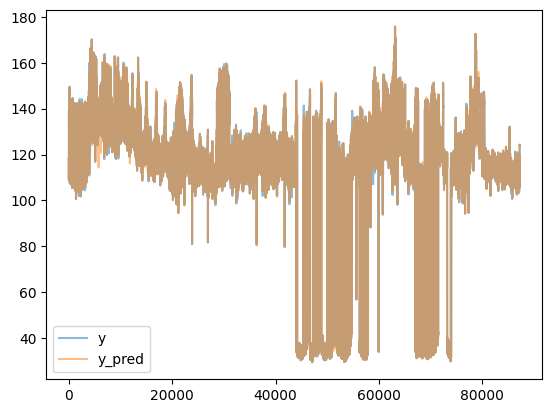

In [63]:
import matplotlib.pyplot as plt

plt.plot(y, label='y', alpha = 0.5)
plt.plot(y_pred, label='y_pred', alpha = 0.5)

plt.legend()
plt.show()

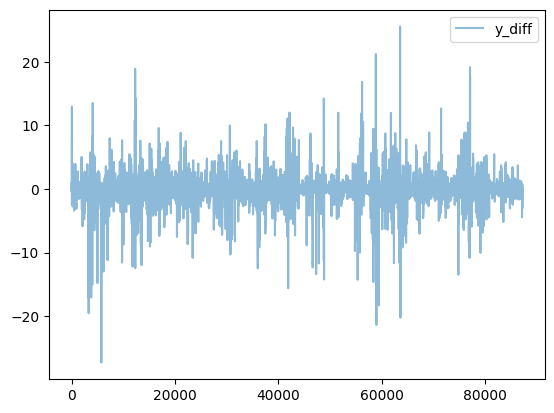

In [64]:
plt.plot(y_diff, label='y_diff', alpha = 0.5)

plt.legend()
plt.show()

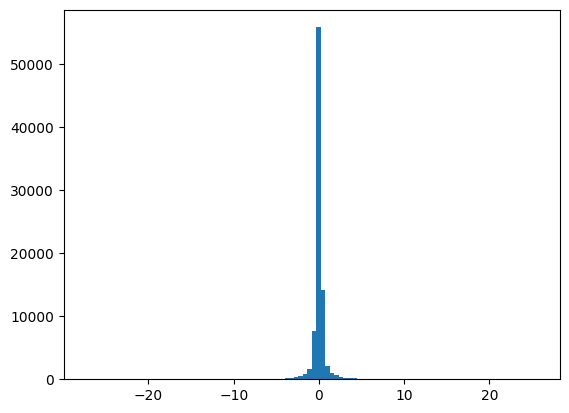

In [65]:
_ = plt.hist(y_diff, bins = 100)

In [66]:
import numpy as np

mae = np.mean(np.abs(y_diff))

rmse = np.sqrt(np.mean(y_diff**2))

print(mae)
print(rmse)
print(np.mean(y_diff), np.std(y_diff))

0.42428359714002256
1.0754820948518307
-0.0015933207898392644 1.0754809146032032


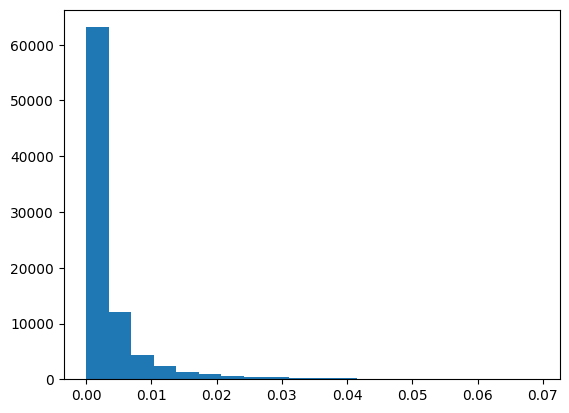

In [67]:
plt.hist(np.sort(np.abs(y_diff/y))[:-200], bins=20)
plt.show()


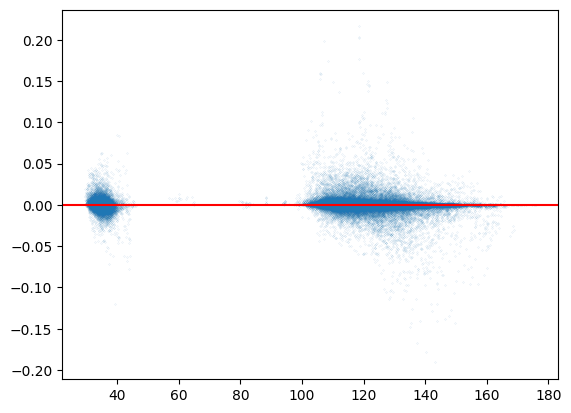

In [68]:
plt.scatter(y, y_diff/y , alpha=0.5, s = 0.01)
plt.axhline(0, color="red")
plt.show()


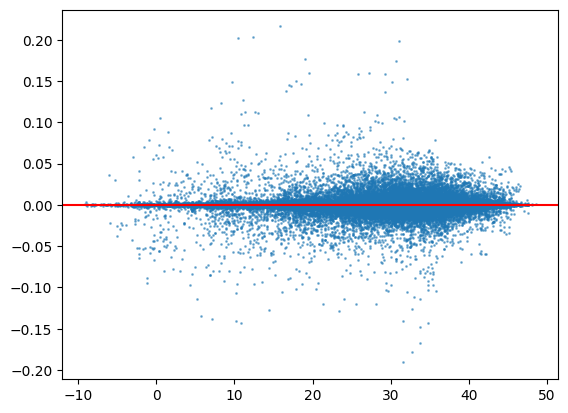

In [69]:
temp = df['temperature_with_5_delay']

plt.scatter(temp, y_diff / y, alpha=0.5, s=1)
plt.axhline(0, color="red")
plt.show()

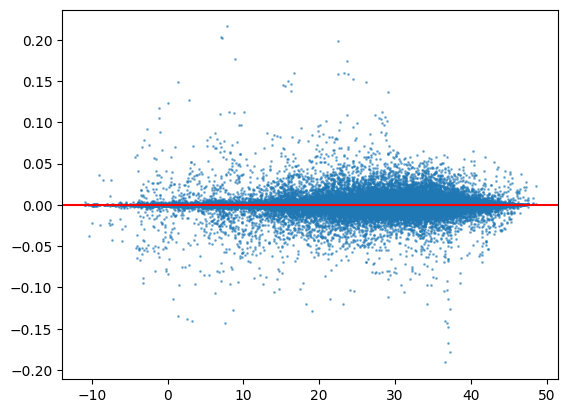

In [70]:
temp = df['temperature']

plt.scatter(temp, y_diff / y, alpha=0.5, s=1)
plt.axhline(0, color="red")
plt.show()

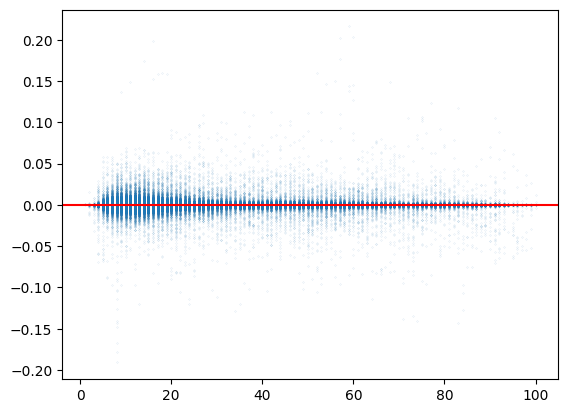

In [71]:
hum = df['humidity']

plt.scatter(hum, y_diff / y, alpha=0.5, s=0.01)
plt.axhline(0, color="red")
plt.show()

In [73]:
from data_selector import Data_selector

power_plants = df[['name', 'code']].drop_duplicates()
for _, row in power_plants.iterrows():
    df_name_code = Data_selector(df).filter_name_code(row['name'], row['code'])
    print(f"{row['name']}, {row['code']}: {100 * len(df_name_code) / len(df) :0.2f}%")

پرند, G12: 2.45%
پرند, G11: 5.27%
پرند, G14: 1.96%
پرند, G16: 1.91%
پرند, G15: 1.97%
پرند, G13: 1.96%
شهدای پیروز - بهبهان, S1: 0.93%
شهدای پیروز - بهبهان, G12: 2.69%
شهدای پیروز - بهبهان, G11: 6.81%
جنوب اصفهان - چهلستون, G14: 1.90%
جنوب اصفهان - چهلستون, G15: 1.66%
جنوب اصفهان - چهلستون, G13: 1.86%
جنوب اصفهان - چهلستون, G12: 1.68%
جنوب اصفهان - چهلستون, G11: 3.44%
سبلان, G13: 1.01%
سبلان, G14: 1.43%
سبلان, G15: 1.35%
جنوب اصفهان - چهلستون, G16: 1.84%
سبلان, G12: 1.74%
سبلان, G11: 4.37%
سیکل ترکیبی ارومیه, G12: 1.00%
سیکل ترکیبی ارومیه, G14: 0.53%
سیکل ترکیبی ارومیه, G13: 0.56%
سیکل ترکیبی ارومیه, G16: 0.72%
سیکل ترکیبی ارومیه, G15: 0.64%
سیکل ترکیبی ارومیه, G11: 2.86%
سیکل ترکیبی یزد, G12: 3.99%
سیکل ترکیبی یزد, G11: 9.78%
سبلان, G16: 1.18%
سیکل ترکیبی شیروان, G11: 1.84%
سیکل ترکیبی شیروان, G16: 0.93%
سیکل ترکیبی شیروان, S1: 0.59%
سیکل ترکیبی شیروان, G15: 0.83%
سبلان, S1: 0.50%
سیکل ترکیبی شیروان, G12: 1.11%
سیکل ترکیبی شیروان, S2: 0.45%
سیکل ترکیبی شیروان, G13: 0.95%
عسلویه, G15: 0

In [74]:
from statsmodels.stats.diagnostic import acorr_ljungbox

result = acorr_ljungbox(y_diff, lags=[10], return_df=True)
print(result)

         lb_stat  lb_pvalue
10  78219.203976        0.0


In [75]:
for _, row in power_plants.iterrows():
    df_name_code = Data_selector(df).filter_name_code(row['name'], row['code'])
    y_nc = df_name_code["generation"].to_numpy()
    y_pred_nc = df_name_code["prediction"].to_numpy()
    
    y_diff_nc = y_pred_nc - y_nc
    
    result = acorr_ljungbox(y_diff_nc, lags=[10], return_df=True)
    result.loc[result["lb_pvalue"] < 0.01 , "lb_pvalue"] = 0
    print(result)
    

        lb_stat  lb_pvalue
10  2784.829115        0.0
        lb_stat  lb_pvalue
10  5011.760843        0.0
        lb_stat  lb_pvalue
10  1837.037138        0.0
        lb_stat  lb_pvalue
10  1270.448965        0.0
        lb_stat  lb_pvalue
10  2855.143973        0.0
        lb_stat  lb_pvalue
10  1877.460534        0.0
       lb_stat  lb_pvalue
10  998.721395        0.0
        lb_stat  lb_pvalue
10  4256.870532        0.0
        lb_stat  lb_pvalue
10  7677.411472        0.0
        lb_stat  lb_pvalue
10  2831.500553        0.0
        lb_stat  lb_pvalue
10  1150.928341        0.0
        lb_stat  lb_pvalue
10  1690.652656        0.0
        lb_stat  lb_pvalue
10  3307.738976        0.0
        lb_stat  lb_pvalue
10  2900.938552        0.0
     lb_stat  lb_pvalue
10  1710.983        0.0
        lb_stat  lb_pvalue
10  1712.326174        0.0
       lb_stat  lb_pvalue
10  1604.24552        0.0
       lb_stat  lb_pvalue
10  2084.37175        0.0
        lb_stat  lb_pvalue
10  1630.6071